# Assignment 4
**Recurrent Neural Network (RNN)**: Use the Google stock prices dataset and design a time series analysis and prediction system using RNN.

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [56]:
# load the dataset
df = pd.read_csv('google_stock_price_train.csv', thousands=',')

In [57]:
# view
df

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,7380500
1,1/4/2012,331.27,333.87,329.08,666.45,5749400
2,1/5/2012,329.83,330.75,326.89,657.21,6590300
3,1/6/2012,328.34,328.77,323.68,648.24,5405900
4,1/9/2012,322.04,322.29,309.46,620.76,11688800
...,...,...,...,...,...,...
1253,12/23/2016,790.90,792.74,787.28,789.91,623400
1254,12/27/2016,790.68,797.86,787.66,791.55,789100
1255,12/28/2016,793.70,794.23,783.20,785.05,1153800
1256,12/29/2016,783.33,785.93,778.92,782.79,744300


### Preprocessing

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1258 non-null   str    
 1   Open    1258 non-null   float64
 2   High    1258 non-null   float64
 3   Low     1258 non-null   float64
 4   Close   1258 non-null   float64
 5   Volume  1258 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 59.1 KB


In [59]:
# convert to datetime
df['Date'] = pd.to_datetime(df['Date'])

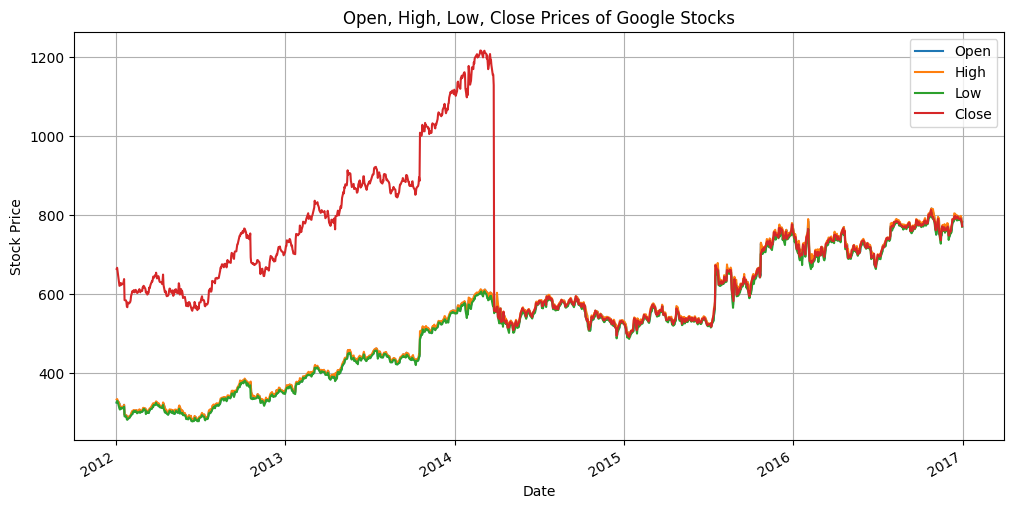

In [60]:
# visualize
fig = df.plot(
    x="Date", 
    y=["Open", "High", "Low", "Close"], 
    figsize=(12, 6),
    title='Open, High, Low, Close Prices of Google Stocks'
)
fig.set_ylabel("Stock Price")
fig.set_xlabel("Date")
plt.grid(True)
plt.show()

In [61]:
# select only features, not date
data = df.drop('Date', axis=1)

In [62]:
# scale data to 0-1 range
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [63]:
# function to create sequences
def create_sequences(data, target_col_index, seq_len=60):
    x, y = [], []
    for i in range(seq_len, len(data)):
        x.append(data[i-seq_len:i])            # shape: (60, num_features)
        y.append(data[i, target_col_index])    # only close price
    return np.array(x), np.array(y)


x, y = create_sequences(scaled_data, target_col_index=3)

In [64]:
# train-test split
split = int(len(x) * 0.8)
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]

### Build & Train LSTM

In [65]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1)  # predicts a single value i.e. close price
])

# compile the model
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/home/amey/Downloads/41335/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,009 (199.25 KB)

 Trainable params: 51,009 (199.25 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
# train the model
history = model.fit(x_train, y_train, epochs=30, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0263 - val_loss: 0.0049
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0065 - val_loss: 0.0042
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0069 - val_loss: 0.0030
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0051 - val_loss: 0.0013
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0055 - val_loss: 6.7490e-04
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0052 - val_loss: 0.0027
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0047 - val_loss: 4.6322e-04
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0045 - val_loss: 0.0011
Epoch 9/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0042 - val_loss: 0.0030
Epoch 10/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0036 - val_loss: 8.6820e-04
Epoch 11/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0040 - val_loss: 0.0020
Epoch 12/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step

In [67]:
from tensorflow.keras.layers import SimpleRNN

# Build SimpleRNN model
model_rnn = Sequential([
    SimpleRNN(128, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])),
    Dropout(0.2),
    SimpleRNN(64),
    Dropout(0.2),
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mean_squared_error')
model_rnn.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 60, 128)        │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,569 (115.50 KB)

 Trainable params: 29,569 (115.50 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
# Train SimpleRNN
history_rnn = model_rnn.fit(x_train, y_train, epochs=80, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.1872 - val_loss: 0.0334
Epoch 2/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0726 - val_loss: 0.0059
Epoch 3/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0496 - val_loss: 0.0031
Epoch 4/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0349 - val_loss: 0.0043
Epoch 5/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0254 - val_loss: 0.0017
Epoch 6/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0225 - val_loss: 0.0121
Epoch 7/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0193 - val_loss: 0.0019
Epoch 8/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0158 - val_loss: 0.0038
Epoch 9/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0136 - val_loss: 2.9531e-04
Epoch 10/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0132 - val_loss: 6.1233e-04
Epoch 11/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0105 - val_loss: 0.0013
Epoch 12/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - l

### Evaluation & Prediction

In [69]:
y_pred = model.predict(x_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [70]:
# Predict using SimpleRNN
y_pred_rnn = model_rnn.predict(x_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [71]:
# dummy scaler to inverse transform Close column only
close_scaler = MinMaxScaler()

# copy over the min_ and scale_ values for the Close column from the original scaler (index 3)
close_scaler.min_, close_scaler.scale_ = scaler.min_[3:4], scaler.scale_[3:4]

In [72]:
# inverse transform
predicted_values = close_scaler.inverse_transform(y_pred)
actual_values = close_scaler.inverse_transform(y_test.reshape(-1, 1))

In [73]:
# Inverse transform RNN predictions
rnn_predicted_values = close_scaler.inverse_transform(y_pred_rnn)

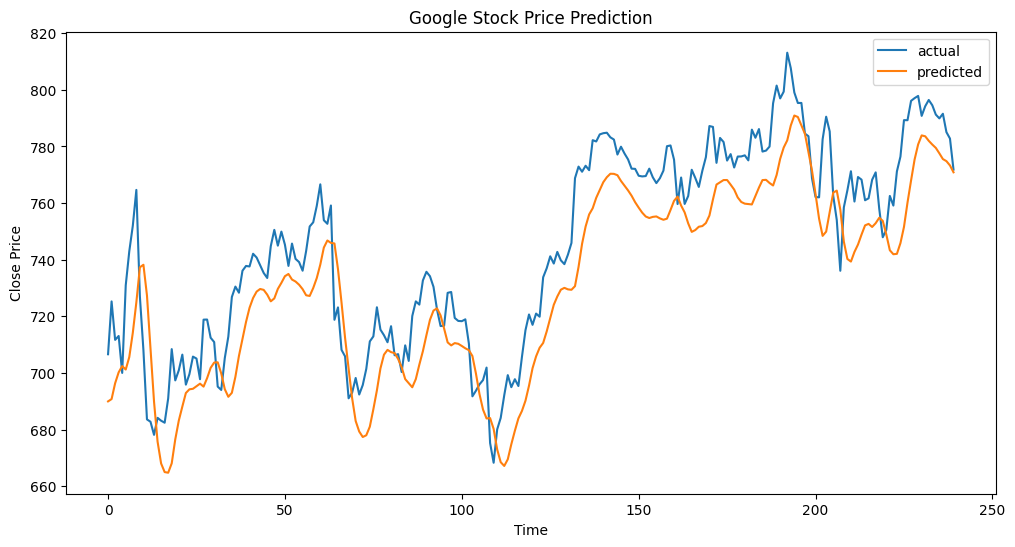

In [74]:
plt.figure(figsize=(12, 6))
plt.plot(actual_values, label='actual')
plt.plot(predicted_values, label='predicted')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [75]:
# metrics
rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
mae = mean_absolute_error(actual_values, predicted_values)
r2 = r2_score(actual_values, predicted_values)

print('RMSE: ', rmse)
print('MAE: ', mae)
print('R2 Score: ', r2)

RMSE:  18.494009383208866
MAE:  16.030996195475257
R2 Score:  0.7135571364128552


In [76]:
# Calculate metrics for RNN
rmse_rnn = np.sqrt(mean_squared_error(actual_values, rnn_predicted_values))
mae_rnn = mean_absolute_error(actual_values, rnn_predicted_values)
r2_rnn = r2_score(actual_values, rnn_predicted_values)

print('=== SimpleRNN ===')
print('RMSE: ', rmse_rnn)
print('MAE: ', mae_rnn)
print('R2 Score: ', r2_rnn)

print('\n=== LSTM ===')
print('RMSE: ', rmse)
print('MAE: ', mae)
print('R2 Score: ', r2)

=== SimpleRNN ===
RMSE:  10.230626590248038
MAE:  7.753156239827477
R2 Score:  0.9123442668402296

=== LSTM ===
RMSE:  18.494009383208866
MAE:  16.030996195475257
R2 Score:  0.7135571364128552


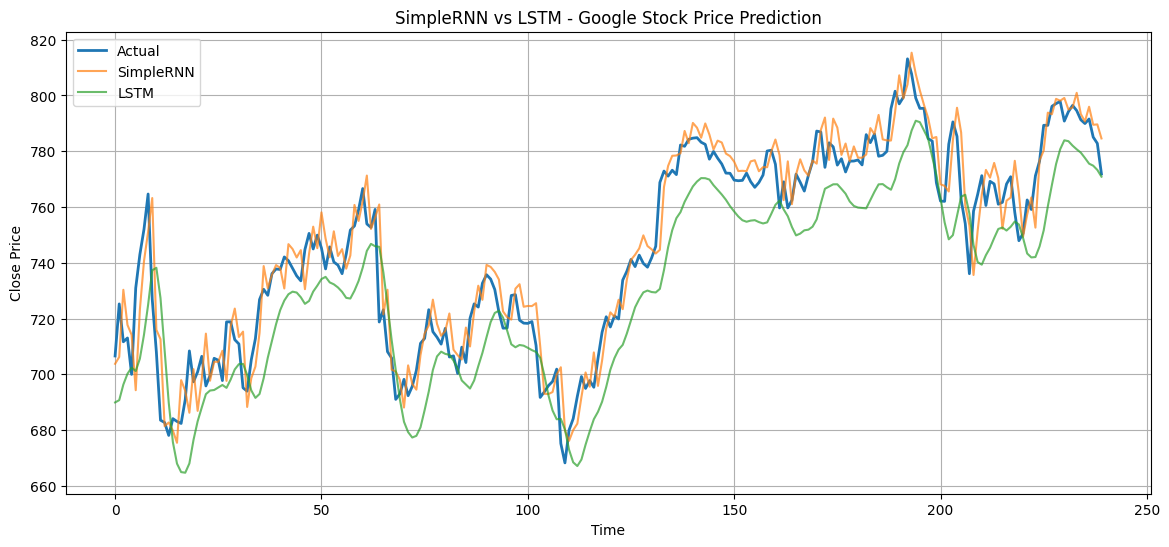

In [77]:
### Comparison: SimpleRNN vs LSTM

# Comparison plot
plt.figure(figsize=(14, 6))
plt.plot(actual_values, label='Actual', linewidth=2)
plt.plot(rnn_predicted_values, label='SimpleRNN', alpha=0.7)
plt.plot(predicted_values, label='LSTM', alpha=0.7)
plt.title('SimpleRNN vs LSTM - Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

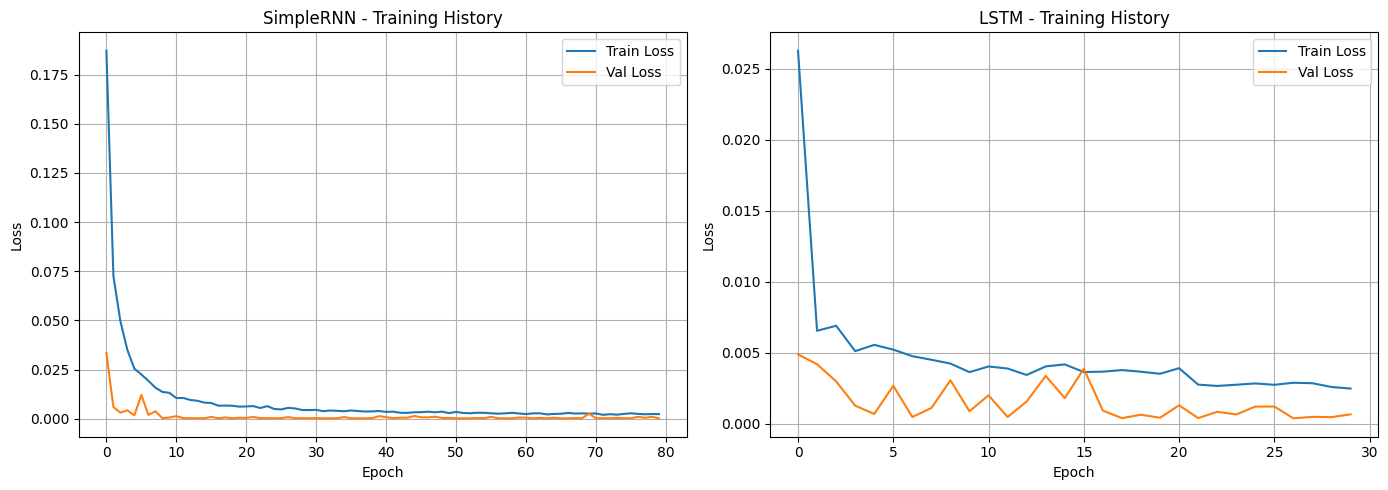

In [78]:
# Loss curves comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RNN Loss
axes[0].plot(history_rnn.history['loss'], label='Train Loss')
axes[0].plot(history_rnn.history['val_loss'], label='Val Loss')
axes[0].set_title('SimpleRNN - Training History')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# LSTM Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('LSTM - Training History')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()